### Packages and Frameworks

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds

from tensorflow import keras

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from collections import Counter

2025-09-01 23:48:57.212994: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-01 23:48:57.280323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 23:48:58.420795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Auxiliary Functions

In [2]:
def sturges_bins(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = len(x)
    if n <= 1:
        return 1, np.inf

    k = math.ceil(math.log2(n)) + 1
    data_range = x.max() - x.min()
    h = data_range / k if data_range > 0 else np.inf
    h = math.ceil(h)
    
    return k, h

### Questão 2

O conjunto de dados Wine  Quality  Dataset contém medições físico-químicas de vinhos (como acidez, teor alcoólico e pH) e uma nota de qualidade atribuída por especialistas. Esse problema é amplamente utilizado para estudo de classificação supervisionada, pois envolve a 
relação entre variáveis químicas e uma avaliação subjetiva de qualidade. Aplique as técnicas de pré-processamento de dados vistas em salas de aula. Em seguida, divida os dados em conjuntos  de  treinamento  e  de  teste,  e  implemente  e  treine  uma  Rede  Perceptron  de 
Múltiplas Camadas (MLP) para classificar a qualidade de vinhos.

Apresente  também  as  curvas  de  erro  de  treinamento  e  validação,  e  calcule  a  matriz  de confusão. 
 
Algumas recomendações:  
* Verifique a existência de valores ausentes ou inconsistentes e trate-os adequadamente.
* Analise  a distribuição da variável-alvo e verifique se há desbalanceamento entre as classes.  
* Calcule correlações entre atributos e o rótulo de qualidade, removendo ou mantendo atributos com base nessa análise. 
* Aplique normalização ou padronização das variáveis numéricas, justificando a escolha. 
* Registre e compare estatísticas antes e depois do pré-processamento. 

#### Data Reading

In [3]:
ds_red = tfds.load("wine_quality/red", split="train", as_supervised=False)
ds_white = tfds.load("wine_quality/white", split="train", as_supervised=False)

W0000 00:00:1756781340.485952  164666 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


#### Data Processing

In [4]:
df_red = tfds.as_dataframe(ds_red)
df_white = tfds.as_dataframe(ds_white)

df_red["type"] = "red"
df_white["type"] = "white"

df = pd.concat([df_red, df_white], ignore_index=True)

df.type = LabelEncoder().fit_transform(df.type)

min_quality = np.min(df.quality)
df.quality -= min_quality

for column_name in df.columns:
    new_name = column_name.replace("features/", "")
    df.rename(columns={column_name: new_name}, inplace=True)

display(df.head())
display(df.info())
display(df.describe())

2025-09-01 23:49:00.705355: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2025-09-01 23:49:01.071151: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-01 23:49:02.327460: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity,quality,type
0,10.55,0.050,0.06,0.99236,6.0,38.0,3.30,1.8,0.50,89.0,0.54,3,0
1,11.60,0.086,0.31,1.00020,8.7,23.0,3.48,3.0,0.74,81.0,0.69,3,0
2,11.70,0.012,0.28,0.99064,6.7,36.0,3.26,2.4,0.39,100.0,0.28,4,0
3,9.50,0.078,0.24,0.99830,7.5,10.0,3.45,2.0,0.78,28.0,0.55,3,0
4,9.20,0.088,0.26,0.99810,7.8,23.0,3.41,2.0,0.74,48.0,0.54,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   alcohol               6497 non-null   float32
 1   chlorides             6497 non-null   float32
 2   citric acid           6497 non-null   float32
 3   density               6497 non-null   float32
 4   fixed acidity         6497 non-null   float32
 5   free sulfur dioxide   6497 non-null   float32
 6   pH                    6497 non-null   float32
 7   residual sugar        6497 non-null   float32
 8   sulphates             6497 non-null   float64
 9   total sulfur dioxide  6497 non-null   float32
 10  volatile acidity      6497 non-null   float32
 11  quality               6497 non-null   int32  
 12  type                  6497 non-null   int64  
dtypes: float32(10), float64(1), int32(1), int64(1)
memory usage: 380.8 KB


None

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,0.056034,0.318633,0.994697,7.215307,30.525320,3.218501,5.443235,0.531268,115.744576,0.339666,2.818378,0.753886
std,1.192711,0.035033,0.145319,0.002999,1.296448,17.749403,0.160786,4.757818,0.148806,56.521889,0.164636,0.873255,0.430779
min,8.000000,0.009000,0.000000,0.987110,3.800000,1.000000,2.720000,0.600000,0.220000,6.000000,0.080000,0.000000,0.000000
25%,9.500000,0.038000,0.250000,0.992340,6.400000,17.000000,3.110000,1.800000,0.430000,77.000000,0.230000,2.000000,1.000000
50%,10.300000,0.047000,0.310000,0.994890,7.000000,29.000000,3.210000,3.000000,0.510000,118.000000,0.290000,3.000000,1.000000
75%,11.300000,0.065000,0.390000,0.996990,7.700000,41.000000,3.320000,8.100000,0.600000,156.000000,0.400000,3.000000,1.000000
max,14.900000,0.611000,1.660000,1.038980,15.900000,289.000000,4.010000,65.800003,2.000000,440.000000,1.580000,6.000000,1.000000


Text(0.5, 1.0, 'Wine Quality')

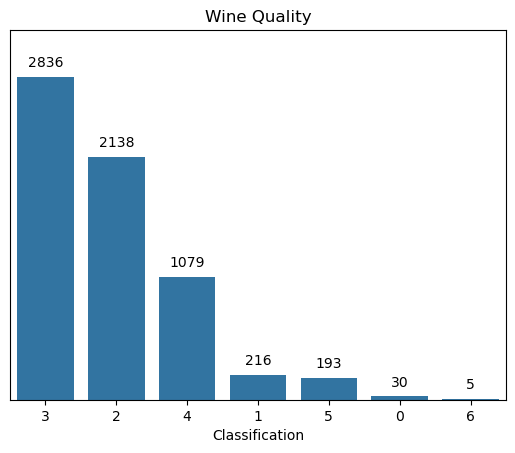

In [5]:
# Counter Plot

order = df["quality"].value_counts().index

plt.figure()
ax = sns.countplot(data=df, x="quality", order=order)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

ax.yaxis.set_visible(False)
plt.ylim([0, 3250])
plt.xlabel("Classification")
plt.title("Wine Quality")

In [6]:
# Remove the Minority Class

# df = df[df.quality != 6]

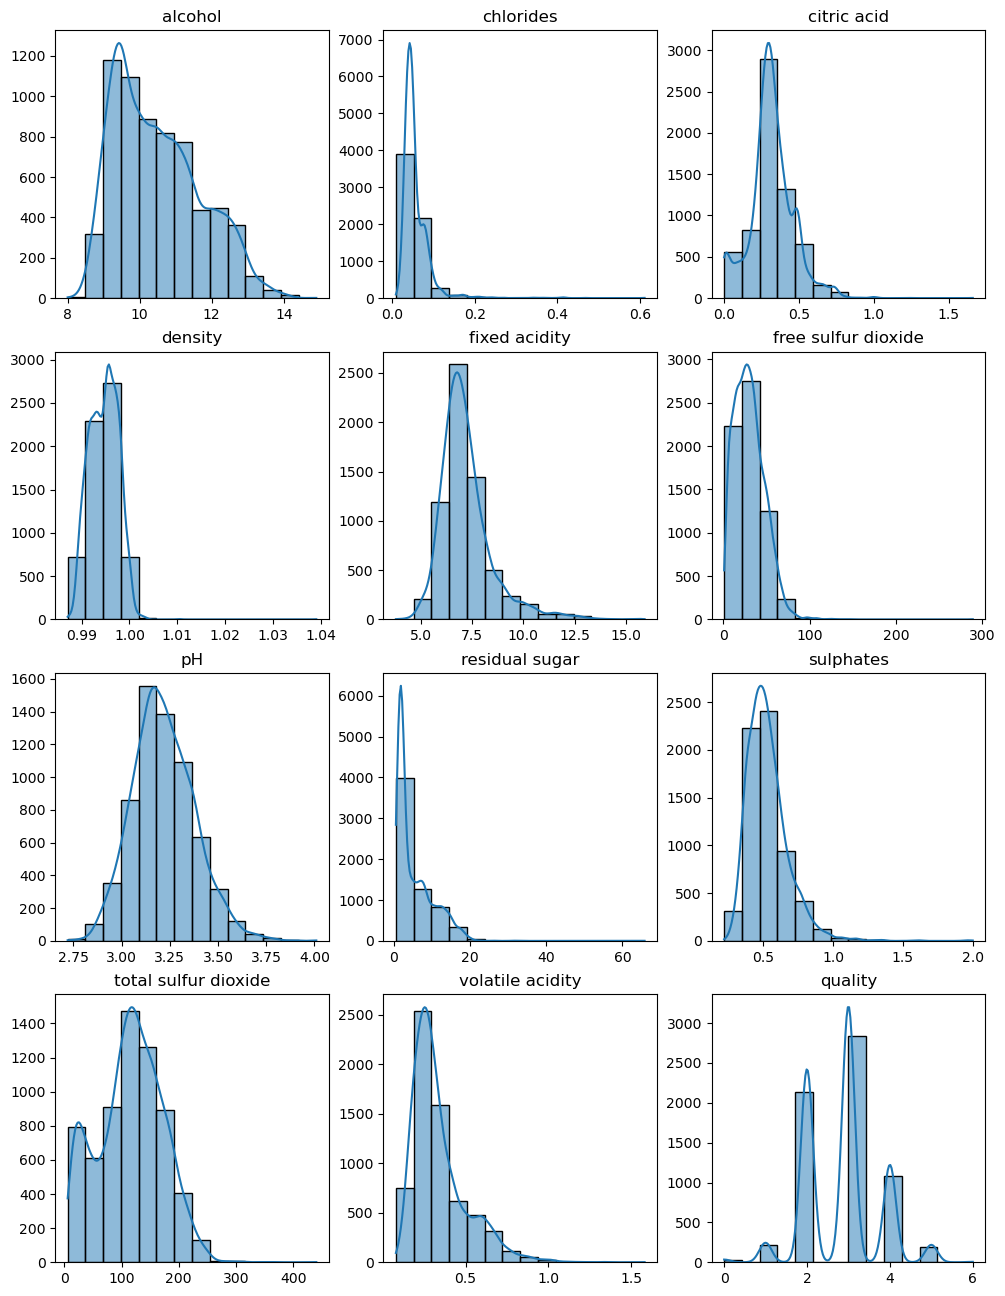

In [7]:
# Plot of Histograms

fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(12, 16))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    if col != "type":
        data = df[col].values
        k, _ = sturges_bins(data)

        sns.histplot(data=data, bins=k, kde=True, ax=axes[idx])
        axes[idx].set_title(f"{col.replace("features/", "")}")
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")

#### Model

In [8]:
# Data

num_classes = len(df.quality.unique())

X = df.loc[:, df.columns[df.columns != "quality"]].values

y = df.loc[:, "quality"].values
# y = keras.utils.to_categorical(y, num_classes=num_classes)

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test_full, y_train, y_test_full = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test_full, y_test_full, test_size=0.5, random_state=42
)

In [9]:
# smote = SMOTE(sampling_strategy="auto", random_state=42)

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# print(pd.Series(y_train_resampled).value_counts())

In [10]:
# class_weights_array = compute_class_weight(
#     class_weight="balanced", classes=np.unique(y_train_resampled), y=y_train_resampled
# )
# class_weights_dict = dict(zip(np.unique(y_train_resampled), class_weights_array))

# print(class_weights_array)

In [11]:
# Model

# Building the Layers

input_ = keras.layers.Input(shape=X_train.shape[1:])

hidden1 = keras.layers.Dense(200, activation="relu")(input_)
dropout1 = keras.layers.Dropout(0.3)(hidden1)

hidden2 = keras.layers.Dense(100, activation="relu")(dropout1)
dropout2 = keras.layers.Dropout(0.3)(hidden2)

hidden3 = keras.layers.Dense(50, activation="relu")(dropout2)
dropout3 = keras.layers.Dropout(0.3)(hidden3)

output = keras.layers.Dense(num_classes, activation="softmax")(dropout3)

# Model Configuration

model = keras.Model(inputs=[input_], outputs=[output])

custom_optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    loss="sparse_categorical_crossentropy", optimizer=custom_optimizer, metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,107 (109.79 KB)

 Trainable params: 28,107 (109.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_valid, y_valid),
    # class_weight=class_weights_dict,
)

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4247 - loss: 1.3786 - val_accuracy: 0.4800 - val_loss: 1.1541
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4911 - loss: 1.1867 - val_accuracy: 0.5446 - val_loss: 1.1004
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5047 - loss: 1.1580 - val_accuracy: 0.5123 - val_loss: 1.1005
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5232 - loss: 1.1438 - val_accuracy: 0.5431 - val_loss: 1.0764
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5143 - loss: 1.1282 - val_accuracy: 0.5492 - val_loss: 1.0662
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5274 - loss: 1.1167 - val_accuracy: 0.5508 - val_loss: 1.0702
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5365 - loss: 1.1039 - val_accuracy: 0.5415 - val_loss: 1.0591
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5276 - loss: 1.1034 - val_accu

<Figure size 640x480 with 0 Axes>

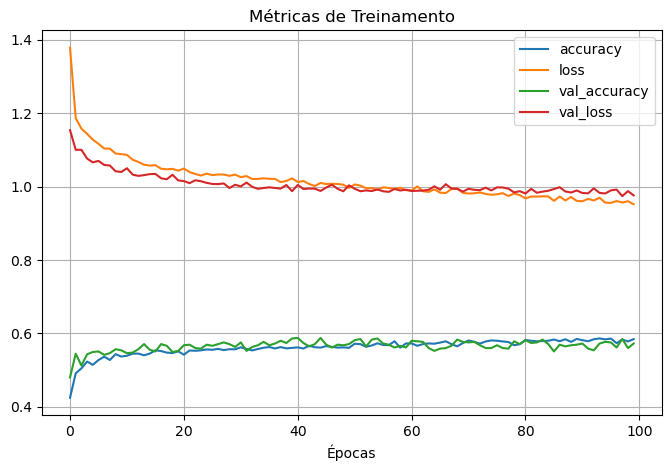

In [13]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

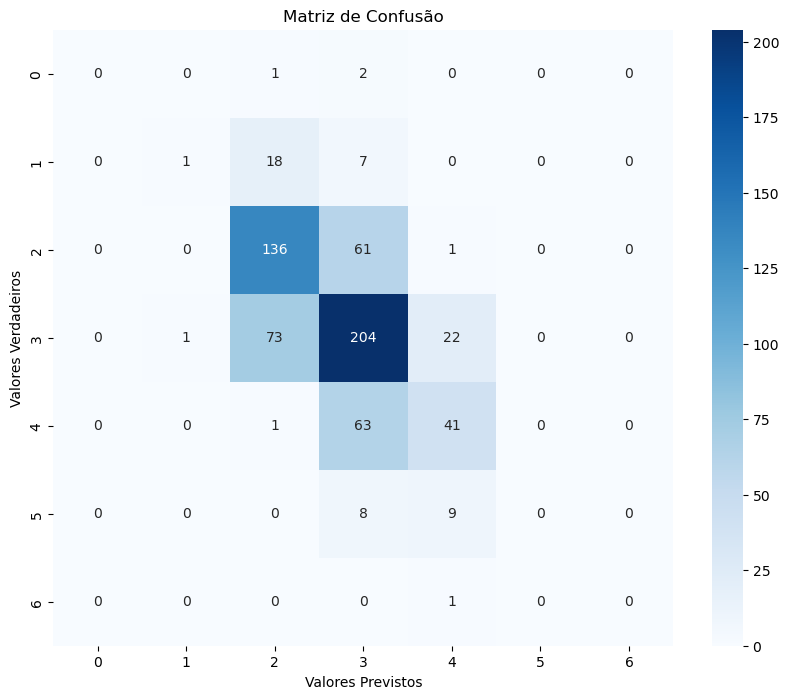

Acurácia do modelo: 59%


In [14]:
# Metrics

y_pred = np.argmax(y_pred, axis=1)

# Confusion Matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Valores Previstos")
plt.ylabel("Valores Verdadeiros")
plt.title("Matriz de Confusão")
plt.show()

# Accuracy

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print(f"Acurácia do modelo: {int(round(accuracy*100, 0))}%")